<a href="https://colab.research.google.com/github/Dokkae-bi/Intro-to-DL-Summer-26/blob/main/Homework4/Homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 4

## Problem 1: Character-Level Transformer vs. RNN Comparison

In [1]:
# ===== Cell 1: Vocabulary + Encoding =====
import torch
import torch.nn as nn
import time

# --- Reproducibility ---
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
import numpy as np
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# The text provided in the assignment
text = """Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."""

# Build the vocabulary: every unique character, sorted for reproducibility
chars = sorted(set(text))
vocab_size = len(chars)

# Two-way mapping between characters and integer indices
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for i, ch in enumerate(chars)}

# Encode the whole essay as a list of integers
encoded = [char2idx[ch] for ch in text]

# --- Sanity checks ---
print("Total characters in essay:", len(text))
print("Vocabulary size:", vocab_size)
print("Vocabulary:", chars)
print("First 20 chars  :", repr(text[:20]))
print("First 20 encoded:", encoded[:20])
decoded = ''.join(idx2char[i] for i in encoded[:20])
print("Round-trip OK   :", decoded == text[:20])

Device: cuda
Total characters in essay: 2391
Vocabulary size: 45
Vocabulary: ['\n', ' ', "'", '(', ')', ',', '-', '.', 'A', 'D', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
First 20 chars  : 'Next character predi'
First 20 encoded: [13, 23, 42, 38, 1, 21, 26, 19, 36, 19, 21, 38, 23, 36, 1, 34, 36, 23, 22, 27]
Round-trip OK   : True


In [2]:
# ===== P1 Cell 2: Sliding windows as integer indices (embedding replaces one-hot) =====

def build_dataset_idx(encoded, seq_length, device):
    """Same sliding window as HW2, but X stays integer indices for nn.Embedding."""
    X, y = [], []
    for i in range(len(encoded) - seq_length):
        X.append(encoded[i : i + seq_length])
        y.append(encoded[i + seq_length])
    X = torch.tensor(X, dtype=torch.long)
    y = torch.tensor(y, dtype=torch.long)
    return X.to(device), y.to(device)

for sl in [10, 20, 30]:
    X, y = build_dataset_idx(encoded, sl, device)
    print(f"seq_length={sl:2d}:  X={tuple(X.shape)}  y={tuple(y.shape)}")

seq_length=10:  X=(2381, 10)  y=(2381,)
seq_length=20:  X=(2371, 20)  y=(2371,)
seq_length=30:  X=(2361, 30)  y=(2361,)


In [3]:
# ===== P1 Cell 3 (v2): Positional encoding + character transformer (pre-norm) =====
import math

class PositionalEncoding(nn.Module):
    """Adds a fixed sin/cos pattern so the model knows token order.
    Self-attention alone is order-blind -- without this, 'dog bites man'
    and 'man bites dog' would look identical."""
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class CharTransformer(nn.Module):
    """Embed -> add positions -> N transformer blocks -> classify from last token."""
    def __init__(self, vocab_size, d_model=128, nhead=2, num_layers=2,
                 dim_ff=256, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEncoding(d_model)
        block = nn.TransformerEncoderLayer(d_model, nhead, dim_ff, dropout,
                                           batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(block, num_layers)
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        h = self.embed(x) * math.sqrt(self.d_model)
        h = self.pos(h)
        h = self.encoder(h)
        return self.fc(h[:, -1, :])

In [4]:
# ===== P1 Cell 4 (v2): harness with count_params bundled in =====

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def train_eval_tf(seq_length, d_model=128, nhead=2, num_layers=2, dropout=0.1,
                  epochs=100, lr=0.001, batch_size=64, clip=1.0, verbose=True):
    torch.manual_seed(SEED)
    X, y = build_dataset_idx(encoded, seq_length, device)
    N = X.shape[0]

    model = CharTransformer(vocab_size, d_model, nhead, num_layers,
                            dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history, best_loss = [], float('inf')
    start = time.time()
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(N, device=device)
        epoch_loss = 0.0
        for i in range(0, N, batch_size):
            idx = perm[i:i+batch_size]
            optimizer.zero_grad()
            loss = criterion(model(X[idx]), y[idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            epoch_loss += loss.item() * idx.size(0)
        epoch_loss /= N
        loss_history.append(epoch_loss)
        best_loss = min(best_loss, epoch_loss)
        if verbose and epoch % 20 == 0:
            print(f"  epoch {epoch:3d}  loss {epoch_loss:.4f}")
    train_time = time.time() - start

    model.eval()
    with torch.no_grad():
        val_acc = (model(X).argmax(1) == y).float().mean().item()

    return {'model': 'transformer', 'seq': seq_length,
            'final_loss': loss_history[-1], 'best_loss': best_loss,
            'val_acc': val_acc, 'time': train_time,
            'params': count_params(model), 'loss_history': loss_history}

In [5]:
# ===== P1 Cell 5: Run seq lengths 10/20/30 and compare to HW2 RNNs =====

tf_results = []
for sl in [10, 20, 30]:
    print(f"Training TRANSFORMER @ seq_length={sl} ...")
    r = train_eval_tf(sl, epochs=200, lr=0.001, dropout=0.0, verbose=False)
    tf_results.append(r)

print(f"\n{'model':12s} {'seq':>3s} {'params':>8s} {'final':>7s} "
      f"{'best':>7s} {'acc':>6s} {'time_s':>7s}")
for r in tf_results:
    print(f"{'TRANSFORMER':12s} {r['seq']:>3d} {r['params']:>8,d} "
          f"{r['final_loss']:>7.3f} {r['best_loss']:>7.3f} "
          f"{r['val_acc']:>6.3f} {r['time']:>7.1f}")

Training TRANSFORMER @ seq_length=10 ...


/tmp/ipykernel_19263/1422649334.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(block, num_layers)


Training TRANSFORMER @ seq_length=20 ...


/tmp/ipykernel_19263/1422649334.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(block, num_layers)


Training TRANSFORMER @ seq_length=30 ...

model        seq   params   final    best    acc  time_s
TRANSFORMER   10  276,525   0.311   0.250  0.934    44.8
TRANSFORMER   20  276,525   0.307   0.270  0.935    44.5
TRANSFORMER   30  276,525   0.374   0.365  0.894    43.7


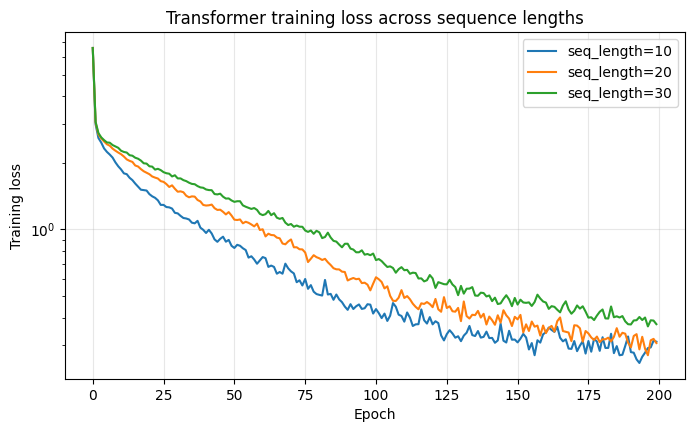

In [6]:
# ===== P1 Cell 6: Loss curves =====
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
for r in tf_results:
    plt.plot(r['loss_history'], label=f"seq_length={r['seq']}")
plt.xlabel("Epoch"); plt.ylabel("Training loss")
plt.yscale('log')
plt.title("Transformer training loss across sequence lengths")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Problem 2: Transformer for Character Prediction on Tiny Shakespeare

In [7]:
# ===== P2 Cell 1: Tiny Shakespeare data + loaders (from HW2) =====
from torch.utils.data import Dataset, DataLoader
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text_shake = requests.get(url).text

chars_shake = sorted(list(set(text_shake)))
vocab_size_shake = len(chars_shake)
char_to_int = {ch: i for i, ch in enumerate(chars_shake)}
int_to_char = {i: ch for i, ch in enumerate(chars_shake)}
encoded_text = [char_to_int[ch] for ch in text_shake]

print("Total characters:", len(text_shake))
print("Vocabulary size:", vocab_size_shake)

class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

def make_loaders(seq_length, batch_size=128):
    """Sliding windows + reproducible 80/20 split + loaders (same as HW2)."""
    seqs, tgts = [], []
    for i in range(0, len(encoded_text) - seq_length):
        seqs.append(encoded_text[i:i+seq_length])
        tgts.append(encoded_text[i+seq_length])
    seqs = torch.tensor(seqs, dtype=torch.long)
    tgts = torch.tensor(tgts, dtype=torch.long)
    ds = CharDataset(seqs, tgts)
    train_size = int(len(ds) * 0.8)
    test_size = len(ds) - train_size
    train_ds, test_ds = torch.utils.data.random_split(
        ds, [train_size, test_size],
        generator=torch.Generator().manual_seed(SEED))
    train_loader = DataLoader(train_ds, shuffle=True, batch_size=batch_size)
    test_loader  = DataLoader(test_ds, shuffle=False, batch_size=batch_size)
    return train_loader, test_loader

Total characters: 1115394
Vocabulary size: 65


In [8]:
# ===== P2 Cell 2: Transformer harness for tiny Shakespeare =====

@torch.no_grad()
def evaluate_tf(model, loader):
    """Average loss + next-char accuracy over the test loader (mirrors HW2)."""
    model.eval()
    crit = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    for seq, target in loader:
        seq, target = seq.to(device), target.to(device)
        logits = model(seq)
        total_loss += crit(logits, target).item() * seq.size(0)
        correct += (logits.argmax(1) == target).sum().item()
        total += seq.size(0)
    return total_loss / total, correct / total

def train_eval_p2_tf(train_loader, test_loader, vocab_size,
                     d_model=128, nhead=2, num_layers=2, dim_ff=256,
                     epochs=5, lr=0.001, clip=1.0, verbose=True):
    torch.manual_seed(SEED)
    model = CharTransformer(vocab_size, d_model, nhead, num_layers,
                            dim_ff=dim_ff, dropout=0.1).to(device)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    start = time.time()
    for epoch in range(epochs):
        model.train()
        running, seen = 0.0, 0
        for seq, target in train_loader:
            seq, target = seq.to(device), target.to(device)
            opt.zero_grad()
            loss = crit(model(seq), target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            running += loss.item() * seq.size(0); seen += seq.size(0)
        train_loss = running / seen
        test_loss, test_acc = evaluate_tf(model, test_loader)
        if verbose:
            print(f"  epoch {epoch+1:2d}  train_loss {train_loss:.4f}  "
                  f"test_loss {test_loss:.4f}  test_acc {test_acc:.4f}")
    train_time = time.time() - start

    return {'d_model': d_model, 'nhead': nhead, 'layers': num_layers,
            'train_loss': train_loss, 'test_loss': test_loss,
            'test_acc': test_acc, 'perplexity': math.exp(test_loss),
            'time': train_time, 'params': count_params(model), 'model_obj': model}

In [9]:
# ===== P2 Cell 3 (v2): Baseline transformer (2 blocks, 2 heads) @ seq 20 and 30 =====

p2_tf_results = []
for sl in [20, 30]:
    train_loader, test_loader = make_loaders(sl)
    print(f"\n=== TRANSFORMER (2 blocks, 2 heads) @ seq_length={sl} ===")
    r = train_eval_p2_tf(train_loader, test_loader, vocab_size_shake,
                         num_layers=2, nhead=2, epochs=5, verbose=True)
    r['seq'] = sl
    p2_tf_results.append(r)

print(f"\n{'seq':>3s} {'params':>8s} {'train_loss':>10s} {'test_acc':>9s} "
      f"{'perplx':>7s} {'time_s':>7s}")
for r in p2_tf_results:
    print(f"{r['seq']:>3d} {r['params']:>8,d} {r['train_loss']:>10.4f} "
          f"{r['test_acc']:>9.4f} {r['perplexity']:>7.3f} {r['time']:>7.1f}")


=== TRANSFORMER (2 blocks, 2 heads) @ seq_length=20 ===


/tmp/ipykernel_19263/1422649334.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(block, num_layers)


  epoch  1  train_loss 2.4275  test_loss 2.1471  test_acc 0.3776
  epoch  2  train_loss 2.1238  test_loss 1.9769  test_acc 0.4118
  epoch  3  train_loss 2.0098  test_loss 1.8980  test_acc 0.4380
  epoch  4  train_loss 1.9460  test_loss 1.8377  test_acc 0.4465
  epoch  5  train_loss 1.9019  test_loss 1.7952  test_acc 0.4648

=== TRANSFORMER (2 blocks, 2 heads) @ seq_length=30 ===
  epoch  1  train_loss 2.4594  test_loss 2.1547  test_acc 0.3754
  epoch  2  train_loss 2.1256  test_loss 1.9939  test_acc 0.4088
  epoch  3  train_loss 2.0146  test_loss 1.9028  test_acc 0.4374
  epoch  4  train_loss 1.9528  test_loss 1.8435  test_acc 0.4514
  epoch  5  train_loss 1.9094  test_loss 1.8050  test_acc 0.4651

seq   params train_loss  test_acc  perplx  time_s
 20  281,665     1.9019    0.4648   6.021   260.3
 30  281,665     1.9094    0.4651   6.080   266.4


In [10]:
# ===== P2 Cell 4: Architecture sweep @ seq_length=20 =====

SWEEP_SEQ = 20
train_loader, test_loader = make_loaders(SWEEP_SEQ)

sweep_grid = [(1, 2), (1, 4), (2, 2), (2, 4), (4, 2), (4, 4), (2, 8), (4, 8)]

tf_sweep_results = []
for n_blocks, n_heads in sweep_grid:
    print(f"\n=== TRANSFORMER | blocks={n_blocks}, heads={n_heads} ===")
    r = train_eval_p2_tf(train_loader, test_loader, vocab_size_shake,
                         num_layers=n_blocks, nhead=n_heads,
                         epochs=5, verbose=True)
    tf_sweep_results.append(r)

print(f"\n{'blocks':>6s} {'heads':>5s} {'params':>8s} {'tr_loss':>8s} "
      f"{'test_loss':>9s} {'test_acc':>9s} {'perplx':>7s} {'time_s':>7s}")
for r in tf_sweep_results:
    print(f"{r['layers']:>6d} {r['nhead']:>5d} {r['params']:>8,d} "
          f"{r['train_loss']:>8.4f} {r['test_loss']:>9.4f} "
          f"{r['test_acc']:>9.4f} {r['perplexity']:>7.3f} {r['time']:>7.1f}")


=== TRANSFORMER | blocks=1, heads=2 ===


/tmp/ipykernel_19263/1422649334.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(block, num_layers)


  epoch  1  train_loss 2.4687  test_loss 2.2189  test_acc 0.3581
  epoch  2  train_loss 2.2177  test_loss 2.0901  test_acc 0.3849
  epoch  3  train_loss 2.1200  test_loss 2.0020  test_acc 0.4083
  epoch  4  train_loss 2.0568  test_loss 1.9472  test_acc 0.4185
  epoch  5  train_loss 2.0132  test_loss 1.9120  test_acc 0.4330

=== TRANSFORMER | blocks=1, heads=4 ===
  epoch  1  train_loss 2.4471  test_loss 2.1787  test_acc 0.3713
  epoch  2  train_loss 2.1597  test_loss 2.0352  test_acc 0.4043
  epoch  3  train_loss 2.0574  test_loss 1.9477  test_acc 0.4252
  epoch  4  train_loss 1.9925  test_loss 1.9001  test_acc 0.4322
  epoch  5  train_loss 1.9504  test_loss 1.8498  test_acc 0.4525

=== TRANSFORMER | blocks=2, heads=2 ===
  epoch  1  train_loss 2.4275  test_loss 2.1471  test_acc 0.3776
  epoch  2  train_loss 2.1238  test_loss 1.9769  test_acc 0.4118
  epoch  3  train_loss 2.0098  test_loss 1.8980  test_acc 0.4380
  epoch  4  train_loss 1.9460  test_loss 1.8377  test_acc 0.4465
  epoch 

In [11]:
# ===== P2 Cell 5: seq_length = 50 =====
train_loader_50, test_loader_50 = make_loaders(50)
print("=== TRANSFORMER (2 blocks, 2 heads) @ seq_length=50 ===")
r50 = train_eval_p2_tf(train_loader_50, test_loader_50, vocab_size_shake,
                       num_layers=2, nhead=2, epochs=5, verbose=True)
print(f"\nseq=50: params={r50['params']:,}  test_acc={r50['test_acc']:.4f}  "
      f"perplexity={r50['perplexity']:.3f}  time={r50['time']:.1f}s")

=== TRANSFORMER (2 blocks, 2 heads) @ seq_length=50 ===


/tmp/ipykernel_19263/1422649334.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(block, num_layers)


  epoch  1  train_loss 2.4895  test_loss 2.1704  test_acc 0.3671
  epoch  2  train_loss 2.1412  test_loss 1.9937  test_acc 0.4139
  epoch  3  train_loss 2.0226  test_loss 1.9110  test_acc 0.4358
  epoch  4  train_loss 1.9562  test_loss 1.8391  test_acc 0.4564
  epoch  5  train_loss 1.9093  test_loss 1.8141  test_acc 0.4575

seq=50: params=281,665  test_acc=0.4575  perplexity=6.136  time=270.8s


In [12]:
# ===== P2 Cell 6: Generation quality — best sweep config vs baseline =====

@torch.no_grad()
def generate_tf(model, seed_str, length=500, temperature=0.8, context_len=20):
    """Autoregressive sampling, same pattern as HW2's generate_shakespeare.
    context_len should match the model's training sequence length."""
    model.eval()
    context = [char_to_int[c] for c in seed_str]
    generated = seed_str
    for _ in range(length):
        x = torch.tensor(context[-context_len:], device=device).unsqueeze(0)
        logits = model(x)[0] / temperature
        probs = torch.softmax(logits, dim=0)
        nxt = torch.multinomial(probs, 1).item()
        generated += int_to_char[nxt]
        context.append(nxt)
    return generated

# tf_sweep_results order: (1,2),(1,4),(2,2),(2,4),(4,2),(4,4),(2,8),(4,8)
baseline_model = tf_sweep_results[2]['model_obj']   # 2 blocks, 2 heads
best_model     = tf_sweep_results[7]['model_obj']   # 4 blocks, 8 heads

seed = "ROMEO:"
for name, m in [("BASELINE (2 blocks, 2 heads)", baseline_model),
                ("BEST (4 blocks, 8 heads)", best_model)]:
    print(f"\n{'='*60}\n{name} — temperature 0.8\n{'='*60}")
    print(generate_tf(m, seed, length=400, temperature=0.8, context_len=20))


BASELINE (2 blocks, 2 heads) — temperature 0.8
ROMEO:
Angllose mone that fir in ying.

MENENIUS:
My so suck, that hasge the warrew pesand.

ESCALUS:
My not are noth make Like your way know
Hath ingrow
And stice: flow.
If thou sweel.

DUKE VINCENTIO:
And at hat shalman:
And not worsend extords and more,
Did come this a thouth bally have that to moe reath and his my that thy the stares of a hoppear.

KING HENRY O:
O, my more me siched rease goodle to 

BEST (4 blocks, 8 heads) — temperature 0.8
ROMEO:messssssssse a shall belight: thy worship the fall yeard the proves trother bear the sou!
Who was; sir, if a treath of at not thy exyed.

ANTIGS:
If I will thy sleason?

There father thy earsiness head.

HENRY BOLINGBROKE:
A well; sir, I she care word?

GLOUCESTER:
A work to Burgin: if his of a a forther so say and to her our and a to passion,
By way sorrow not my that a nother paintaget of my wor


In [13]:
# ===== P2 Cell 7: Inference time per configuration (seq 20 test loader) =====

p2_train_loader, p2_test_loader = make_loaders(20)

@torch.no_grad()
def inference_ms_per_batch(model, loader, n_batches=50):
    """Average forward-pass time, mirroring the HW2 inference measurement."""
    model.eval()
    seq, _ = next(iter(loader))
    model(seq.to(device))
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start, done = time.time(), 0
    for seq, _ in loader:
        model(seq.to(device))
        done += 1
        if done >= n_batches:
            break
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return (time.time() - start) / done * 1000

print(f"{'blocks':>6s} {'heads':>5s} {'params':>8s} {'infer_ms':>9s}")
for r in tf_sweep_results:
    r['infer_ms'] = inference_ms_per_batch(r['model_obj'], p2_test_loader)
    print(f"{r['layers']:>6d} {r['nhead']:>5d} {r['params']:>8,d} {r['infer_ms']:>9.3f}")

blocks heads   params  infer_ms
     1     2  149,185     1.295
     1     4  149,185     1.299
     2     2  281,665     1.595
     2     4  281,665     1.631
     4     2  546,625     2.157
     4     4  546,625     2.165
     2     8  281,665     1.586
     4     8  546,625     2.184


In [14]:
# ===== P2 Cell 8: Hidden size (d_model) at 2 blocks x 2 heads, seq 20 =====
p2_train_loader, p2_test_loader = make_loaders(20)

dmodel_results = []
for dm in [64, 256]:
    print(f"\n=== TRANSFORMER | d_model={dm}, dim_ff={2*dm} (2 blocks, 2 heads) ===")
    r = train_eval_p2_tf(p2_train_loader, p2_test_loader, vocab_size_shake,
                         d_model=dm, dim_ff=2*dm,
                         num_layers=2, nhead=2, epochs=5, verbose=True)
    r['infer_ms'] = inference_ms_per_batch(r['model_obj'], p2_test_loader)
    dmodel_results.append(r)

print(f"\n{'d_model':>7s} {'params':>8s} {'test_acc':>9s} {'perplx':>7s} {'time_s':>7s} {'infer_ms':>9s}")
for r in dmodel_results:
    print(f"{r['d_model']:>7d} {r['params']:>8,d} {r['test_acc']:>9.4f} "
          f"{r['perplexity']:>7.3f} {r['time']:>7.1f} {r['infer_ms']:>9.3f}")


=== TRANSFORMER | d_model=64, dim_ff=128 (2 blocks, 2 heads) ===


/tmp/ipykernel_19263/1422649334.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(block, num_layers)


  epoch  1  train_loss 2.3656  test_loss 2.0859  test_acc 0.3843
  epoch  2  train_loss 2.0747  test_loss 1.9653  test_acc 0.4208
  epoch  3  train_loss 1.9915  test_loss 1.8929  test_acc 0.4389
  epoch  4  train_loss 1.9418  test_loss 1.8436  test_acc 0.4526
  epoch  5  train_loss 1.9089  test_loss 1.8076  test_acc 0.4617

=== TRANSFORMER | d_model=256, dim_ff=512 (2 blocks, 2 heads) ===
  epoch  1  train_loss 2.7728  test_loss 2.3112  test_acc 0.3493
  epoch  2  train_loss 2.2534  test_loss 2.0302  test_acc 0.4084
  epoch  3  train_loss 2.1013  test_loss 1.9439  test_acc 0.4297
  epoch  4  train_loss 2.0283  test_loss 1.8980  test_acc 0.4427
  epoch  5  train_loss 1.9792  test_loss 1.8405  test_acc 0.4549

d_model   params  test_acc  perplx  time_s  infer_ms
     64   75,329    0.4617   6.096   259.9     1.599
    256 1,087,553    0.4549   6.300   262.4     1.611


## Problem 3: Transformer-Based Encoder-Decoder for English-to-French Translation

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
# ===== P3 Cell 1: EN-FR data pipeline (consolidated from HW3) =====
import re, random
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

random.seed(42)              # same seed -> identical 80/20 split as HW3
PAD, SOS, EOS, UNK = 0, 1, 2, 3
smooth = SmoothingFunction().method1

DATA_PATH = "/content/drive/MyDrive/vast_english_french.txt"

def normalize(s):
    s = s.lower().strip()
    s = re.sub(r"([?.!,'])", r" \1 ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

raw = open(DATA_PATH, encoding="utf-8").read().splitlines()
pairs = [tuple(normalize(x) for x in line.split("\t"))
         for line in raw if line.count("\t") == 1]

random.shuffle(pairs)
n_val = int(0.2 * len(pairs))
val_pairs   = pairs[:n_val]
train_pairs = pairs[n_val:]
print(f"{len(pairs)} pairs -> {len(train_pairs)} train / {len(val_pairs)} val")

class Vocab:
    def __init__(self):
        self.word2idx = {"<PAD>": PAD, "<SOS>": SOS, "<EOS>": EOS, "<UNK>": UNK}
        self.idx2word = {i: w for w, i in self.word2idx.items()}
    def add_sentence(self, s):
        for w in s.split():
            if w not in self.word2idx:
                i = len(self.word2idx)
                self.word2idx[w] = i
                self.idx2word[i] = w
    def __len__(self):
        return len(self.word2idx)
    def encode(self, s, add_eos=True):
        ids = [self.word2idx.get(w, UNK) for w in s.split()]
        return ids + [EOS] if add_eos else ids
    def decode(self, ids):
        return " ".join(self.idx2word[i] for i in ids if i not in (PAD, SOS, EOS))

eng_vocab, fr_vocab = Vocab(), Vocab()
for en, fr in train_pairs:
    eng_vocab.add_sentence(en)
    fr_vocab.add_sentence(fr)
print(f"English vocab: {len(eng_vocab)} | French vocab: {len(fr_vocab)}")

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab, src_is_english=True):
        self.pairs = pairs
        self.src_vocab, self.tgt_vocab = src_vocab, tgt_vocab
        self.src_is_english = src_is_english
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, i):
        en, fr = self.pairs[i]
        src_txt, tgt_txt = (en, fr) if self.src_is_english else (fr, en)
        src = torch.tensor(self.src_vocab.encode(src_txt), dtype=torch.long)
        tgt = torch.tensor(self.tgt_vocab.encode(tgt_txt), dtype=torch.long)
        return src, tgt

train_ds = TranslationDataset(train_pairs, eng_vocab, fr_vocab, src_is_english=True)
val_ds   = TranslationDataset(val_pairs,   eng_vocab, fr_vocab, src_is_english=True)

555 pairs -> 444 train / 111 val
English vocab: 881 | French vocab: 970


In [18]:
# ===== P3 Cell 1b: Padded batching (upgrade over HW3's batch_size=1) =====
from torch.nn.utils.rnn import pad_sequence

def collate_pairs(batch):
    """Pad a list of (src, tgt) index tensors into rectangular batches.
    Returns tgt_in (with <SOS> prepended) and tgt_out (with <EOS> appended)
    shifted by one -- the transformer predicts tgt_out from tgt_in."""
    srcs, tgts = zip(*batch)
    src_batch = pad_sequence(srcs, batch_first=True, padding_value=PAD)
    tgt_in  = [torch.cat([torch.tensor([SOS]), t[:-1]]) for t in tgts]
    tgt_out = list(tgts)
    tgt_in  = pad_sequence(tgt_in,  batch_first=True, padding_value=PAD)
    tgt_out = pad_sequence(tgt_out, batch_first=True, padding_value=PAD)
    return src_batch, tgt_in, tgt_out

BATCH = 32
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  collate_fn=collate_pairs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, collate_fn=collate_pairs)

# Sanity check
src_b, tin_b, tout_b = next(iter(train_loader))
print("src:", src_b.shape, "| tgt_in:", tin_b.shape, "| tgt_out:", tout_b.shape)
print("tgt_in[0] :", tin_b[0].tolist())
print("tgt_out[0]:", tout_b[0].tolist())

src: torch.Size([32, 11]) | tgt_in: torch.Size([32, 14]) | tgt_out: torch.Size([32, 14])
tgt_in[0] : [1, 109, 422, 37, 423, 424, 0, 0, 0, 0, 0, 0, 0, 0]
tgt_out[0]: [109, 422, 37, 423, 424, 2, 0, 0, 0, 0, 0, 0, 0, 0]


In [19]:
# ===== P3 Cell 2: Seq2Seq Transformer =====

class Seq2SeqTransformer(nn.Module):
    """Encoder-decoder transformer. num_layers and nhead are the sweep knobs.
    Encoder self-attention reads the source; decoder gets causal self-attention
    over the target so far, plus cross-attention over encoder outputs
    (the transformer version of HW3's Luong attention)."""
    def __init__(self, src_vocab, tgt_vocab, d_model=128, nhead=2,
                 num_layers=2, dim_ff=256, dropout=0.1, max_len=50):
        super().__init__()
        self.d_model = d_model
        self.src_embed = nn.Embedding(src_vocab, d_model, padding_idx=PAD)
        self.tgt_embed = nn.Embedding(tgt_vocab, d_model, padding_idx=PAD)
        self.pos = PositionalEncoding(d_model, max_len=max_len)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_layers, num_decoder_layers=num_layers,
            dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True, norm_first=True)
        self.out = nn.Linear(d_model, tgt_vocab)

    def forward(self, src, tgt_in):
        src_pad = (src == PAD)
        tgt_pad = (tgt_in == PAD)
        L = tgt_in.size(1)
        causal = torch.triu(torch.ones(L, L, device=src.device, dtype=torch.bool),
                            diagonal=1)

        s = self.pos(self.src_embed(src) * math.sqrt(self.d_model))
        t = self.pos(self.tgt_embed(tgt_in) * math.sqrt(self.d_model))
        h = self.transformer(s, t, tgt_mask=causal,
                             src_key_padding_mask=src_pad,
                             tgt_key_padding_mask=tgt_pad,
                             memory_key_padding_mask=src_pad)
        return self.out(h)

In [20]:
# ===== P3 Cell 3: Training, greedy decoding, evaluation =====

def run_epoch(model, loader, criterion, opt=None):
    """One pass. With opt: train mode. Without: validation loss."""
    training = opt is not None
    model.train() if training else model.eval()
    total, count = 0.0, 0
    with torch.set_grad_enabled(training):
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            logits = model(src, tgt_in)                      # (B, L, V)
            loss = criterion(logits.reshape(-1, logits.size(-1)),
                             tgt_out.reshape(-1))
            if training:
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            total += loss.item(); count += 1
    return total / count

@torch.no_grad()
def greedy_decode_tf(model, src_ids, max_len=20):
    """Autoregressive: start from <SOS>, append argmax until <EOS>."""
    model.eval()
    src = src_ids.unsqueeze(0).to(device)
    ys = torch.tensor([[SOS]], device=device)
    for _ in range(max_len):
        logits = model(src, ys)
        nxt = logits[0, -1].argmax().item()
        if nxt == EOS:
            break
        ys = torch.cat([ys, torch.tensor([[nxt]], device=device)], dim=1)
    return ys[0, 1:].tolist()

def evaluate_translation(model, pairs, src_vocab, tgt_vocab,
                         src_is_english=True, n_examples=5):
    """Exact-match ('Traditional Sequence Accuracy') + BLEU-4, same as HW3."""
    exact, bleu_total, examples = 0, 0.0, []
    for idx, (en, fr) in enumerate(pairs):
        src_txt, tgt_txt = (en, fr) if src_is_english else (fr, en)
        src = torch.tensor(src_vocab.encode(src_txt), dtype=torch.long)
        ids = greedy_decode_tf(model, src)
        pred_words = [tgt_vocab.idx2word[i] for i in ids]
        tgt_words = tgt_txt.split()
        is_exact = pred_words == tgt_words
        exact += is_exact
        b = sentence_bleu([tgt_words], pred_words,
                          smoothing_function=smooth) if pred_words else 0.0
        bleu_total += b
        if idx < n_examples:
            examples.append((src_txt, tgt_txt, " ".join(pred_words), is_exact, b))
    n = len(pairs)
    return 100 * exact / n, bleu_total / n, examples

In [21]:
# ===== P3 Cell 4: Sweep one direction over all 8 configs =====

CONFIG_GRID = [(1, 2), (1, 4), (2, 2), (2, 4), (4, 2), (4, 4), (2, 8), (4, 8)]

def sweep_direction(src_is_english=True, n_epochs=30, lr=0.001):
    if src_is_english:
        sv, tv, tag = eng_vocab, fr_vocab, "EN->FR"
    else:
        sv, tv, tag = fr_vocab, eng_vocab, "FR->EN"

    tr_ds = TranslationDataset(train_pairs, sv, tv, src_is_english)
    va_ds = TranslationDataset(val_pairs,   sv, tv, src_is_english)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True,  collate_fn=collate_pairs)
    va_loader = DataLoader(va_ds, batch_size=BATCH, shuffle=False, collate_fn=collate_pairs)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD)
    results = []
    for n_blocks, n_heads in CONFIG_GRID:
        torch.manual_seed(SEED)
        model = Seq2SeqTransformer(len(sv), len(tv), nhead=n_heads,
                                   num_layers=n_blocks).to(device)
        opt = optim.Adam(model.parameters(), lr=lr)
        tr_hist, va_hist = [], []
        start = time.time()
        for ep in range(1, n_epochs + 1):
            tr_hist.append(run_epoch(model, tr_loader, criterion, opt))
            va_hist.append(run_epoch(model, va_loader, criterion))
        elapsed = time.time() - start
        acc, bleu, ex = evaluate_translation(model, val_pairs, sv, tv, src_is_english)
        print(f"[{tag}] blocks={n_blocks} heads={n_heads} | "
              f"train {tr_hist[-1]:.4f} | val {va_hist[-1]:.4f} | "
              f"acc {acc:.2f}% | BLEU {bleu:.4f} | {elapsed:.0f}s")
        results.append({'blocks': n_blocks, 'heads': n_heads,
                        'train_loss': tr_hist[-1], 'val_loss': va_hist[-1],
                        'acc': acc, 'bleu': bleu, 'time': elapsed,
                        'params': count_params(model),
                        'tr_hist': tr_hist, 'va_hist': va_hist,
                        'examples': ex, 'model_obj': model})
    return results

# Problem 3: English -> French
p3_results = sweep_direction(src_is_english=True, n_epochs=30)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


[EN->FR] blocks=1 heads=2 | train 0.5980 | val 5.1714 | acc 0.90% | BLEU 0.1225 | 5s
[EN->FR] blocks=1 heads=4 | train 0.4983 | val 5.0065 | acc 0.90% | BLEU 0.1224 | 5s
[EN->FR] blocks=2 heads=2 | train 0.2582 | val 4.7803 | acc 0.00% | BLEU 0.1431 | 8s
[EN->FR] blocks=2 heads=4 | train 0.2068 | val 4.6619 | acc 0.00% | BLEU 0.1312 | 8s
[EN->FR] blocks=4 heads=2 | train 0.1011 | val 4.5291 | acc 0.90% | BLEU 0.1513 | 15s
[EN->FR] blocks=4 heads=4 | train 0.0770 | val 4.5117 | acc 1.80% | BLEU 0.1494 | 15s
[EN->FR] blocks=2 heads=8 | train 0.1653 | val 4.5749 | acc 0.00% | BLEU 0.1397 | 8s
[EN->FR] blocks=4 heads=8 | train 0.0663 | val 4.5445 | acc 0.90% | BLEU 0.1483 | 15s


Best config: 4 blocks, 2 heads | BLEU 0.1513 | exact 0.90%

[FAIL] BLEU 0.063
  in  : he teaches world geography to high school classes
  tgt : il enseigne la géographie mondiale à des classes de lycée
  pred: il enseigne l ' histoire à des enfants du collège

[FAIL] BLEU 0.905
  in  : he plays bass guitar in a professional jazz band
  tgt : il joue de la basse dans un groupe de jazz professionnel
  pred: il joue de la basse dans un groupe de jazz

[FAIL] BLEU 0.000
  in  : the weather forecast predicts heavy snow tomorrow
  tgt : les prévisions météo annoncent de fortes chutes de neige demain
  pred: le temps libre en raison d ' hiver chaud

[FAIL] BLEU 0.139
  in  : she loves to wear long flowing cotton skirts
  tgt : elle adore porter de longues jupes amples en coton
  pred: elle adore porter des jupes longues

[FAIL] BLEU 0.063
  in  : they listen to the professor with absolute attention
  tgt : ils écoutent le professeur avec une attention absolue
  pred: ils écoutent la radio



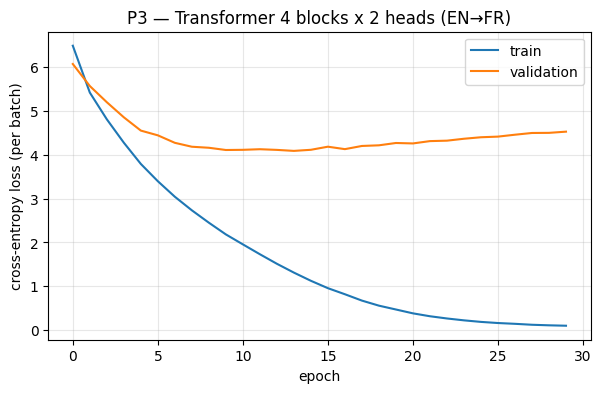

In [22]:
# ===== P3 Cell 5: Qualitative examples + loss curves for the best config =====
import matplotlib.pyplot as plt

best = max(p3_results, key=lambda r: r['bleu'])
print(f"Best config: {best['blocks']} blocks, {best['heads']} heads | "
      f"BLEU {best['bleu']:.4f} | exact {best['acc']:.2f}%\n")

for s, t, p, e, b in best['examples']:
    print(f"[{'PASS' if e else 'FAIL'}] BLEU {b:.3f}")
    print(f"  in  : {s}\n  tgt : {t}\n  pred: {p}\n")

plt.figure(figsize=(7, 4))
plt.plot(best['tr_hist'], label="train")
plt.plot(best['va_hist'], label="validation")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss (per batch)")
plt.title(f"P3 — Transformer {best['blocks']} blocks x {best['heads']} heads (EN→FR)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Problem 4: Reversing the Direction to French-to-English Translation

In [23]:
p4_results = sweep_direction(src_is_english=False, n_epochs=30)

[FR->EN] blocks=1 heads=2 | train 0.5143 | val 5.0544 | acc 0.00% | BLEU 0.1108 | 5s
[FR->EN] blocks=1 heads=4 | train 0.4084 | val 4.9349 | acc 0.00% | BLEU 0.1268 | 5s
[FR->EN] blocks=2 heads=2 | train 0.2027 | val 4.7628 | acc 0.00% | BLEU 0.1286 | 8s
[FR->EN] blocks=2 heads=4 | train 0.1619 | val 4.6401 | acc 0.00% | BLEU 0.1403 | 8s
[FR->EN] blocks=4 heads=2 | train 0.0828 | val 4.5462 | acc 0.00% | BLEU 0.1535 | 15s
[FR->EN] blocks=4 heads=4 | train 0.0635 | val 4.5681 | acc 0.90% | BLEU 0.1632 | 15s
[FR->EN] blocks=2 heads=8 | train 0.1369 | val 4.7001 | acc 0.00% | BLEU 0.1403 | 8s
[FR->EN] blocks=4 heads=8 | train 0.0549 | val 4.4631 | acc 0.90% | BLEU 0.1612 | 15s


Best config: 4 blocks, 4 heads | BLEU 0.1632 | exact 0.90%

[FAIL] BLEU 0.072
  in  : il enseigne la géographie mondiale à des classes de lycée
  tgt : he teaches world geography to high school classes
  pred: he teaches history to middle school children

[FAIL] BLEU 0.181
  in  : il joue de la basse dans un groupe de jazz professionnel
  tgt : he plays bass guitar in a professional jazz band
  pred: he plays bass in a jazz band

[FAIL] BLEU 0.036
  in  : les prévisions météo annoncent de fortes chutes de neige demain
  tgt : the weather forecast predicts heavy snow tomorrow
  pred: the birds chirp in the

[FAIL] BLEU 0.570
  in  : elle adore porter de longues jupes amples en coton
  tgt : she loves to wear long flowing cotton skirts
  pred: she loves to wear long skirts

[FAIL] BLEU 0.364
  in  : ils écoutent le professeur avec une attention absolue
  tgt : they listen to the professor with absolute attention
  pred: they listen to the teacher attentively



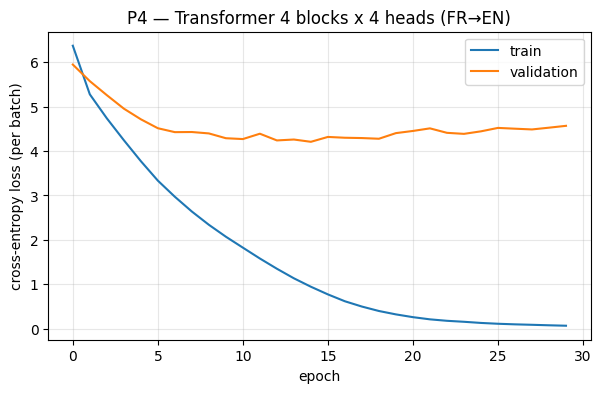

In [24]:
best4 = max(p4_results, key=lambda r: r['bleu'])
print(f"Best config: {best4['blocks']} blocks, {best4['heads']} heads | "
      f"BLEU {best4['bleu']:.4f} | exact {best4['acc']:.2f}%\n")

for s, t, p, e, b in best4['examples']:
    print(f"[{'PASS' if e else 'FAIL'}] BLEU {b:.3f}")
    print(f"  in  : {s}\n  tgt : {t}\n  pred: {p}\n")

plt.figure(figsize=(7, 4))
plt.plot(best4['tr_hist'], label="train")
plt.plot(best4['va_hist'], label="validation")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss (per batch)")
plt.title(f"P4 — Transformer {best4['blocks']} blocks x {best4['heads']} heads (FR→EN)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [25]:
# ===== Appendix: Computational complexity (FLOPs) for all configurations =====
# FLOPs counted with torch.utils.flop_counter (1 multiply-accumulate = 2 FLOPs)
# over one forward pass. Model is put in train mode ONLY so PyTorch uses the
# standard (non-fused) transformer path, where every matmul is visible to the
# counter -- fused inference kernels are invisible to it. FLOPs depend only on
# architecture and input size, never on trained weights, so no training happens.
from torch.utils.flop_counter import FlopCounterMode

def count_flops(model, *inputs):
    model.train()
    fcm = FlopCounterMode(display=False)
    with fcm, torch.no_grad():
        model(*inputs)
    return fcm.get_total_flops()

def fmt(n): return f"{n/1e6:.2f} M"

print("P1: CharTransformer (2 blocks, 2 heads), FLOPs per window")
for L in [10, 20, 30]:
    m = CharTransformer(vocab_size).to(device)
    print(f"  seq {L:2d}: {fmt(count_flops(m, torch.randint(0, vocab_size, (1, L), device=device)))}")

# HW2 RNN comparison, analytic with the same MAC=2 convention:
# per step = 2*gates*(input*hidden + hidden^2); plus the FC head once per window.
def rnn_window_flops(L, in_dim, h, gates, out_dim):
    return L * 2 * gates * (in_dim*h + h*h) + 2 * h * out_dim
print("\nHW2 P1 models (analytic, one-hot 45 -> hidden 128 -> FC 45), per window:")
for name, g in [("RNN", 1), ("GRU", 3), ("LSTM", 4)]:
    print(f"  {name:4s}: " + " | ".join(f"seq {L}: {fmt(rnn_window_flops(L, 45, 128, g, 45))}" for L in [10, 20, 30]))

print("\nP2: CharTransformer vocab 65, seq 20 -- sweep configs (heads do not change FLOPs)")
for nb in [1, 2, 4]:
    m = CharTransformer(vocab_size_shake, num_layers=nb).to(device)
    print(f"  {nb} block(s): {fmt(count_flops(m, torch.randint(0, vocab_size_shake, (1, 20), device=device)))}")
print("P2 d_model variants (2 blocks, 2 heads), seq 20:")
for dm in [64, 128, 256]:
    m = CharTransformer(vocab_size_shake, d_model=dm, dim_ff=2*dm).to(device)
    print(f"  d_model={dm:3d}: {fmt(count_flops(m, torch.randint(0, vocab_size_shake, (1, 20), device=device)))}")
print("P2 baseline (2x2) at each sequence length:")
for L in [20, 30, 50]:
    m = CharTransformer(vocab_size_shake).to(device)
    print(f"  seq {L:2d}: {fmt(count_flops(m, torch.randint(0, vocab_size_shake, (1, L), device=device)))}")
print("HW2 P2 models (analytic, embed 32 -> hidden 128 -> FC 65), per window:")
for name, g in [("GRU", 3), ("LSTM", 4)]:
    print(f"  {name:4s}: " + " | ".join(f"seq {L}: {fmt(rnn_window_flops(L, 32, 128, g, 65))}" for L in [20, 30, 50]))

print("\nP3/P4: Seq2SeqTransformer, per sentence pair (src=8, tgt=8 tokens; dataset average)")
for tag, sv, tv in [("EN->FR", len(eng_vocab), len(fr_vocab)),
                    ("FR->EN", len(fr_vocab), len(eng_vocab))]:
    for nb in [1, 2, 4]:
        m = Seq2SeqTransformer(sv, tv, num_layers=nb).to(device)
        src = torch.randint(4, sv, (1, 8), device=device)
        tgt = torch.randint(4, tv, (1, 8), device=device)
        print(f"  {tag} {nb} block(s): {fmt(count_flops(m, src, tgt))}")

# HW3 GRU comparison (analytic): emb 256, hidden 256, out proj 256 -> target vocab.
def hw3_gru_flops(src_len, tgt_len, out_vocab, attention):
    step = 2 * 3 * (256*256 + 256*256)               # GRU cell, input dim = emb = 256
    total = (src_len + tgt_len) * step + tgt_len * 2 * 256 * out_vocab
    if attention:                                     # dot scores + weighted sum + concat layer
        total += tgt_len * (2*src_len*256 + 2*src_len*256 + 2*512*256)
    return total
print("\nHW3 GRU models (analytic), per pair (src=8, tgt=8):")
for tag, ov in [("EN->FR", len(fr_vocab)), ("FR->EN", len(eng_vocab))]:
    print(f"  {tag} baseline : {fmt(hw3_gru_flops(8, 8, ov, False))}")
    print(f"  {tag} attention: {fmt(hw3_gru_flops(8, 8, ov, True))}")

P1: CharTransformer (2 blocks, 2 heads), FLOPs per window
  seq 10: 5.36 M
  seq 20: 10.91 M
  seq 30: 16.66 M

HW2 P1 models (analytic, one-hot 45 -> hidden 128 -> FC 45), per window:
  RNN : seq 10: 0.45 M | seq 20: 0.90 M | seq 30: 1.34 M
  GRU : seq 10: 1.34 M | seq 20: 2.67 M | seq 30: 4.00 M
  LSTM: seq 10: 1.78 M | seq 20: 3.55 M | seq 30: 5.33 M

P2: CharTransformer vocab 65, seq 20 -- sweep configs (heads do not change FLOPs)
  1 block(s): 5.46 M
  2 block(s): 10.91 M
  4 block(s): 21.81 M
P2 d_model variants (2 blocks, 2 heads), seq 20:
  d_model= 64: 2.83 M
  d_model=128: 10.91 M
  d_model=256: 42.80 M
P2 baseline (2x2) at each sequence length:
  seq 20: 10.91 M
  seq 30: 16.67 M
  seq 50: 28.79 M
HW2 P2 models (analytic, embed 32 -> hidden 128 -> FC 65), per window:
  GRU : seq 20: 2.47 M | seq 30: 3.70 M | seq 50: 6.16 M
  LSTM: seq 20: 3.29 M | seq 30: 4.93 M | seq 50: 8.21 M

P3/P4: Seq2SeqTransformer, per sentence pair (src=8, tgt=8 tokens; dataset average)


/tmp/ipykernel_19263/1422649334.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(block, num_layers)


  EN->FR 1 block(s): 7.33 M
  EN->FR 2 block(s): 12.67 M
  EN->FR 4 block(s): 23.35 M
  FR->EN 1 block(s): 7.15 M
  FR->EN 2 block(s): 12.49 M
  FR->EN 4 block(s): 23.17 M

HW3 GRU models (analytic), per pair (src=8, tgt=8):
  EN->FR baseline : 16.56 M
  EN->FR attention: 18.72 M
  FR->EN baseline : 16.19 M
  FR->EN attention: 18.35 M


In [26]:
# ===== Appendix B: Early stopping at the validation minimum (best configs) =====
# Addresses the overfitting question directly: retrain each direction's best
# configuration, checkpoint the weights at the epoch of minimum validation
# loss, and compare BLEU/exact-match at that checkpoint vs. the final epoch.
import copy

def early_stop_experiment(src_is_english, n_blocks, n_heads, n_epochs=30, lr=0.001):
    if src_is_english:
        sv, tv, tag = eng_vocab, fr_vocab, "EN->FR"
    else:
        sv, tv, tag = fr_vocab, eng_vocab, "FR->EN"
    tr_ds = TranslationDataset(train_pairs, sv, tv, src_is_english)
    va_ds = TranslationDataset(val_pairs,   sv, tv, src_is_english)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True,  collate_fn=collate_pairs)
    va_loader = DataLoader(va_ds, batch_size=BATCH, shuffle=False, collate_fn=collate_pairs)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD)

    torch.manual_seed(SEED)   # same seed as the sweep -> same training trajectory
    model = Seq2SeqTransformer(len(sv), len(tv), nhead=n_heads,
                               num_layers=n_blocks).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)

    best_val, best_ep, best_state = float('inf'), -1, None
    for ep in range(1, n_epochs + 1):
        run_epoch(model, tr_loader, criterion, opt)
        vl = run_epoch(model, va_loader, criterion)
        if vl < best_val:                              # checkpoint at the val minimum
            best_val, best_ep = vl, ep
            best_state = copy.deepcopy(model.state_dict())

    acc_final, bleu_final, _ = evaluate_translation(model, val_pairs, sv, tv, src_is_english)
    model.load_state_dict(best_state)                  # roll back to the val-min epoch
    acc_es, bleu_es, _ = evaluate_translation(model, val_pairs, sv, tv, src_is_english)

    print(f"[{tag}] {n_blocks} blocks x {n_heads} heads")
    print(f"  final epoch {n_epochs:2d}                : BLEU {bleu_final:.4f} | exact {acc_final:.2f}%")
    print(f"  early stop  epoch {best_ep:2d} (val {best_val:.4f}): BLEU {bleu_es:.4f} | exact {acc_es:.2f}%\n")

early_stop_experiment(src_is_english=True,  n_blocks=4, n_heads=2)   # P3 best
early_stop_experiment(src_is_english=False, n_blocks=4, n_heads=4)   # P4 best

[EN->FR] 4 blocks x 2 heads
  final epoch 30                : BLEU 0.1513 | exact 0.90%
  early stop  epoch 14 (val 4.0902): BLEU 0.0938 | exact 0.00%

[FR->EN] 4 blocks x 4 heads
  final epoch 30                : BLEU 0.1632 | exact 0.90%
  early stop  epoch 15 (val 4.2080): BLEU 0.1313 | exact 0.00%

